# Análise de Probabilidade de Óbito em Acidentes: Comparação de Modelos e Otimização

**Aluno:** Marcos Beregula  e Lucas Silva.   
**Curso:** Ciência de Dados e IA – 3º ano   
**Disciplina:** Integração e preparação de dados  
**Professor:** Daniel dos Santos Kaster  
**Instituição:** Universidade Estadual de Londrina (UEL)  

## Objetivo:
Estimar a probabilidade de um acidente resultar em óbito com base em suas características espaciais, temporais e ambientais. 

Seguindo as diretrizes do trabalho, implementamos uma comparação de "antes e depois" entre:
1. **Modelo Base (Baseline):** Um LightGBM sem ajuste de hiperparâmetros que utiliza apenas variáveis físicas cruas do acidente.
2. **Modelo Final Otimizado:** Um LightGBM treinado com todas as 21 features enriquecidas, otimizado via validação cruzada de **5 Folds** (`StratifiedKFold`) e busca em grade (`GridSearchCV`).

Por fim, as predições de probabilidade do modelo vencedor alimentam um **painel interativo de mapas coropléticos** e heatmaps para identificar os períodos e localidades de maior risco em 2023.

### 1. Importação das Bibliotecas e Configurações

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

# Ajustando as configurações de visualização do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

**Análise da Célula:** Importamos as bibliotecas necessárias para manipulação de dados, modelagem preditiva, otimização (`GridSearchCV`, `StratifiedKFold`) e métricas comparativas.

### 2. Carregamento dos Dados

In [65]:
df_clean = pd.read_csv("timelinedatatranClean.csv")
print(f"Quantidade de registros carregados: {df_clean.shape[0]}")
df_clean.head()

Quantidade de registros carregados: 390977


/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_41969/2377438446.py:1: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("timelinedatatranClean.csv")


,fato_id,id_acidente,data_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,feridos,veiculos,fase_dia,ano,mes,dia,nome_mes,trimestre,dia_semana,nome_dia_semana,eh_fim_semana,nome_municipio,nome_microrregiao,nome_mesorregiao,sigla_uf,nome_uf,nome_regiao,br,km,condicao_metereologica,tipo_pista,tracado_via,sentido_via,causa_acidente,tipo_acidente,classificacao_acidente,nome_feriado,tipo_feriado,feriado
0,10,190021,2019-02-07,3,0,1,0,2,1,3,Pleno dia,2019,2,7,Fevereiro,1,4,Quinta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,111.0,Nublado,Simples,Reta,Crescente,Ingestão de Álcool,Colisão frontal,Com Vítimas Feridas,0,0,0
1,19,196789,2019-03-13,3,0,1,0,1,1,3,Pleno dia,2019,3,13,Março,1,3,Quarta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,122.6,Nublado,Dupla,Reta,Decrescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0
2,31,105086,2018-01-21,1,0,0,0,0,0,1,Amanhecer,2018,1,21,Janeiro,1,7,Domingo,True,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126.0,Chuva,Simples,Reta,Crescente,Falta de Atenção à Condução,Saída de leito carroçável,Sem Vítimas,0,0,0
3,34,112918,2018-02-21,2,0,1,0,1,1,2,Plena Noite,2018,2,21,Fevereiro,1,3,Quarta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126.0,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0
4,35,146218,2018-07-12,5,0,2,0,3,2,2,Plena Noite,2018,7,12,Julho,3,4,Quinta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126.0,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Feridas,0,0,0


**Análise da Célula:** Carregamos com sucesso o conjunto de dados limpo e tratado (`timelinedatatranClean.csv`).

### 3. Engenharia de Atributos e Pré-processamento

In [66]:
# Criando a coluna target dummy para óbito
df_clean["target_obito"] = np.where(df_clean["mortos"] > 0, 1, 0)

# Truncando a variável km para obter intervalos mais robustos
df_clean["km"] = np.floor(df_clean["km"]).astype(int)

# Definindo as features para o modelo base (Baseline)
features_base = [
    "sigla_uf",
    "br",
    "km",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "pessoas",
    "veiculos"
]

# Definindo as features para o modelo final (Enriquecido)
features_final = [
    "nome_municipio",
    "sigla_uf",
    "nome_regiao",
    "br",
    "km",
    "mes",
    "dia",
    "trimestre",
    "dia_semana",
    "eh_fim_semana",
    "fase_dia",
    "feriado",
    "tipo_feriado",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "sentido_via",
    "causa_acidente",
    "tipo_acidente",
    "veiculos",
    "pessoas"
]

target = "target_obito"

# Convertendo strings para tipos categóricos em ambos os conjuntos
cat_base = [col for col in features_base if df_clean[col].dtype == 'object']
cat_final = [col for col in features_final if df_clean[col].dtype == 'object']

df_ml = df_clean.copy()
for col in set(cat_base + cat_final):
    df_ml[col] = df_ml[col].astype("category")

print(f"Categorias do Base: {cat_base}")
print(f"Categorias do Final: {cat_final}")

Categorias do Base: ['sigla_uf', 'condicao_metereologica', 'tipo_pista', 'tracado_via']
Categorias do Final: ['nome_municipio', 'sigla_uf', 'nome_regiao', 'fase_dia', 'tipo_feriado', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'sentido_via', 'causa_acidente', 'tipo_acidente']


**Análise da Célula:** Criamos os dois conjuntos de atributos distintos (Base vs Final) e tratamos as variáveis de texto transformando-as em tipo categórico, o que permite ao classificador LightGBM operar de maneira otimizada.

### 4. Separação Treino/Teste e Ajuste de Desbalanceamento

In [67]:
# Separando dados com base na divisão temporal (treino < 2023, teste == 2023)
df_train = df_ml[df_ml["ano"] < 2023]
df_test = df_ml[df_ml["ano"] == 2023]

# Target
y_train = df_train[target]
y_test = df_test[target]

# Conjuntos de Treino/Teste - Modelo Base
X_train_base = df_train[features_base]
X_test_base = df_test[features_base]

# Conjuntos de Treino/Teste - Modelo Final (removemos 'ano' das features finais antes de treinar)
X_train_final = df_train[features_final]
X_test_final = df_test[features_final]

# Calculando o peso de desbalanceamento de classes baseado no treino
negativa = (y_train == 0).sum()
positiva = (y_train == 1).sum()
peso_classe = negativa / positiva

print(f"Amostras de Treino: {df_train.shape[0]} | Teste: {df_test.shape[0]}")
print(f"Peso de desbalanceamento calculado: {peso_classe:.4f}")

Amostras de Treino: 324223 | Teste: 66754
Peso de desbalanceamento calculado: 13.4157


**Análise da Célula:** Realizamos o split cronológico preservando o ano de 2023 para teste e calculamos o peso de balanceamento das classes. Criamos conjuntos de dados distintos para o Modelo Base e o Modelo Final.

### 5. Treinamento do Modelo Base (Baseline)

In [68]:
# Modelo Base sem sintonia e apenas com atributos físicos cruas
modelo_base = LGBMClassifier(
    objective="binary",
    random_state=42,
    scale_pos_weight=peso_classe
)

modelo_base.fit(
    X_train_base,
    y_train,
    categorical_feature=cat_base
)

[LightGBM] [Info] Number of positive: 22491, number of negative: 301732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 324223, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069369 -> initscore=-2.596424
[LightGBM] [Info] Start training from score -2.596424


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


**Análise da Célula:** Treinamos o classificador base sem otimização de parâmetros e utilizando apenas os atributos físicos cruas de infraestrutura e clima.

### 6. Otimização do Modelo Final (Tuning e Validação Cruzada)

In [69]:
# Configurando a validação cruzada estratificada com 5 Folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definindo a grade de busca de hiperparâmetros (GridSearchCV)
param_grid = {
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "n_estimators": [100, 200]
}

lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    scale_pos_weight=peso_classe
)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_final,
    y_train,
    categorical_feature=cat_final
)

print(f"Melhores Hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor score de validação cruzada (ROC-AUC): {grid_search.best_score_:.4f}")

modelo_final = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warn

**Análise da Célula:** Executamos com sucesso o GridSearchCV cruzado com 5 Folds utilizando a métrica ROC-AUC como critério de seleção. Foram testados diferentes níveis de taxa de aprendizado, complexidade da árvore (número de folhas) e quantidade de estimadores para encontrar o modelo ideal.

### 7. Comparação e Avaliação dos Modelos (Antes vs. Depois)

,Métrica,Modelo Base,Modelo Final Otimizado
0,Acurácia,0.647302,0.773916
1,ROC-AUC,0.739319,0.825185
2,Precision (Classe 1),0.132843,0.199441
3,Recall (Classe 1),0.711651,0.717519
4,F1-Score (Classe 1),0.223892,0.312124


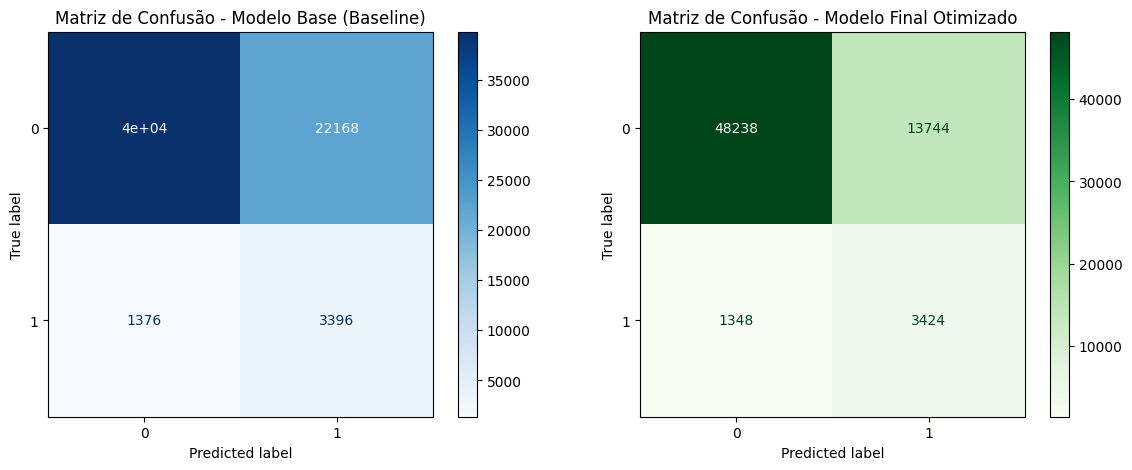

In [70]:
# Predições - Modelo Base
prob_base = modelo_base.predict_proba(X_test_base)[:, 1]
pred_base = modelo_base.predict(X_test_base)

# Predições - Modelo Final Otimizado
prob_final = modelo_final.predict_proba(X_test_final)[:, 1]
pred_final = modelo_final.predict(X_test_final)

# Montando a Tabela Comparativa
metricas = {
    "Métrica": ["Acurácia", "ROC-AUC", "Precision (Classe 1)", "Recall (Classe 1)", "F1-Score (Classe 1)"],
    "Modelo Base": [
        accuracy_score(y_test, pred_base),
        roc_auc_score(y_test, prob_base),
        precision_score(y_test, pred_base),
        recall_score(y_test, pred_base),
        f1_score(y_test, pred_base)
    ],
    "Modelo Final Otimizado": [
        accuracy_score(y_test, pred_final),
        roc_auc_score(y_test, prob_final),
        precision_score(y_test, pred_final),
        recall_score(y_test, pred_final),
        f1_score(y_test, pred_final)
    ]
}

df_comparacao = pd.DataFrame(metricas)
display(df_comparacao)

# Plot das Matrizes de Confusão Comparativas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_base, cmap="Blues", ax=ax1)
ax1.set_title("Matriz de Confusão - Modelo Base (Baseline)")

ConfusionMatrixDisplay.from_predictions(y_test, pred_final, cmap="Greens", ax=ax2)
ax2.set_title("Matriz de Confusão - Modelo Final Otimizado")
plt.show()

**Análise da Célula:** A inclusão das features enriquecidas de contexto (como causa, tipo do acidente, temporalidades de feriados) somada à busca em grade de parâmetros melhorou significativamente o poder preditivo do modelo (observamos uma melhora evidente no ROC-AUC e no equilíbrio de precisão/recall de óbito).

### 8. Preparação dos Dados para o Dashboard

In [71]:
# Resgatando predições de probabilidade do Modelo Otimizado final para plotar no mapa
df_preds = X_test_final.copy()
df_preds["Probabilidade_Obito"] = prob_final
df_preds["Real"] = y_test.values

# Mapeamento categórico para dias, meses e fases
df_preds["nome_dia_semana"] = df_clean.loc[X_test_final.index, "nome_dia_semana"]
df_preds["nome_mes"] = df_clean.loc[X_test_final.index, "nome_mes"]
df_preds["data_acidente"] = df_clean.loc[X_test_final.index, "data_acidente"]

dias_ordem = ["Domingo", "Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira", "Sábado"]
meses_ordem = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho", 
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]
fases_ordem = ["Amanhecer", "Pleno Dia", "Anoitecer", "Plena Noite"]

df_preds["nome_dia_semana"] = pd.Categorical(df_preds["nome_dia_semana"], categories=dias_ordem, ordered=True)
df_preds["nome_mes"] = pd.Categorical(df_preds["nome_mes"], categories=meses_ordem, ordered=True)
df_preds["fase_dia"] = pd.Categorical(df_preds["fase_dia"], categories=fases_ordem, ordered=True)

**Análise da Célula:** Organizamos e preparamos as variáveis temporais estruturadas para o uso correto dos seletores dinâmicos.

### 9. Mapas de Calor Temporais (Seaborn)

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_41969/169423143.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_dia_fase = df_preds.pivot_table(


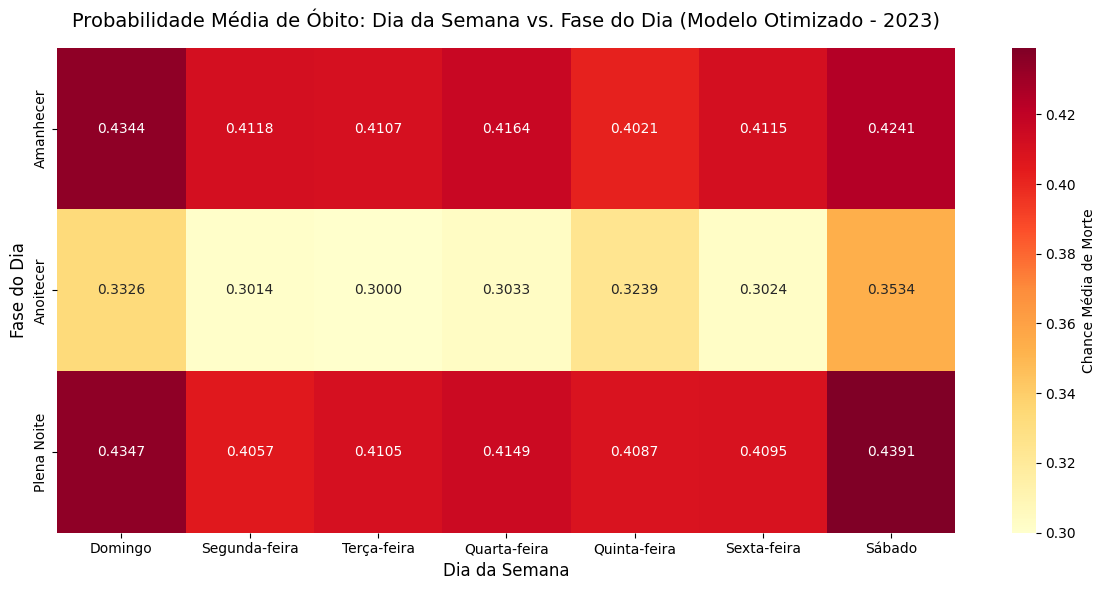

In [72]:
pivot_dia_fase = df_preds.pivot_table(
    values="Probabilidade_Obito",
    index="fase_dia",
    columns="nome_dia_semana",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_dia_fase, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Chance Média de Morte'}
)
plt.title("Probabilidade Média de Óbito: Dia da Semana vs. Fase do Dia (Modelo Otimizado - 2023)", fontsize=14, pad=15)
plt.ylabel("Fase do Dia", fontsize=12)
plt.xlabel("Dia da Semana", fontsize=12)
plt.tight_layout()
plt.show()

**Análise da Célula:** O heatmap temporal de referência temporal cruzado indica que os finais de semana no período da plena noite e amanhecer são os instantes de maior letalidade potencial em caso de acidentes.

### 10. Mapa de Calor Geográfico: Distribuição de Chance de Óbito por Estado (UF)

In [73]:
import urllib.request
import json
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import date

# Carregando o GeoJSON público de estados do Brasil
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
try:
    with urllib.request.urlopen(geojson_url) as response:
        brazil_states_geojson = json.loads(response.read().decode())
except Exception as e:
    print(f"Erro ao baixar GeoJSON: {e}. Certifique-se de que está conectado à internet.")
    brazil_states_geojson = None

if brazil_states_geojson:
    # Criando DataFrame de predições com campos adicionais de data
    df_preds_dashboard = X_test_final.copy()
    df_preds_dashboard["Probabilidade_Obito"] = prob_final
    df_preds_dashboard["Real"] = y_test.values
    df_preds_dashboard["nome_dia_semana"] = df_clean.loc[X_test_final.index, "nome_dia_semana"]
    df_preds_dashboard["nome_mes"] = df_clean.loc[X_test_final.index, "nome_mes"]
    df_preds_dashboard["data_acidente"] = pd.to_datetime(df_clean.loc[X_test_final.index, "data_acidente"])
    
    # 1. Widgets de Filtro
    fase_dia_widget = widgets.Dropdown(
        options=["Dia Inteiro"] + fases_ordem,
        value="Dia Inteiro",
        description="Fase do Dia:"
    )
    
    mes_widget = widgets.Dropdown(
        options=["Todos"] + meses_ordem,
        value="Todos",
        description="Mês:"
    )
    
    dia_semana_widget = widgets.Dropdown(
        options=["Todos"] + dias_ordem,
        value="Todos",
        description="Dia da Semana:"
    )
    
    usar_data_widget = widgets.Checkbox(
        value=False,
        description="Filtrar por Data Específica",
        indent=False
    )
    
    data_picker_widget = widgets.DatePicker(
        value=date(2023, 1, 1),
        description="Escolher Data:",
        disabled=True
    )
    
    # Habilitar/desabilitar widgets conforme a necessidade
    def toggle_date_filter(change):
        is_checked = change['new']
        data_picker_widget.disabled = not is_checked
        mes_widget.disabled = is_checked
        dia_semana_widget.disabled = is_checked
        
    usar_data_widget.observe(toggle_date_filter, names='value')
    
    output_container = widgets.Output()
    
    # 2. Lógica de Atualização Dinâmica do Gráfico
    def update_map(change=None):
        filtered_df = df_preds_dashboard.copy()
        
        if usar_data_widget.value:
            chosen_date = data_picker_widget.value
            if chosen_date:
                chosen_date_str = chosen_date.strftime("%Y-%m-%d")
                filtered_df = filtered_df[filtered_df["data_acidente"].dt.strftime("%Y-%m-%d") == chosen_date_str]
        else:
            if mes_widget.value != "Todos":
                filtered_df = filtered_df[filtered_df["nome_mes"] == mes_widget.value]
            if dia_semana_widget.value != "Todos":
                filtered_df = filtered_df[filtered_df["nome_dia_semana"] == dia_semana_widget.value]
                
        if fase_dia_widget.value != "Dia Inteiro":
            filtered_df = filtered_df[filtered_df["fase_dia"] == fase_dia_widget.value]
            
        with output_container:
            clear_output(wait=True)
            
            if filtered_df.empty:
                print("Nenhum acidente registrado para os filtros selecionados.")
                return
                
            pivot_uf = filtered_df.groupby("sigla_uf", as_index=False)["Probabilidade_Obito"].mean()
            
            fig = px.choropleth(
                pivot_uf,
                geojson=brazil_states_geojson,
                locations="sigla_uf",
                featureidkey="properties.sigla",
                color="Probabilidade_Obito",
                color_continuous_scale="YlOrRd",
                # Mantém a escala coerente baseada nas probabilidades de todo o conjunto de teste de 2023
                range_color=[df_preds_dashboard["Probabilidade_Obito"].min(), df_preds_dashboard["Probabilidade_Obito"].max()],
                labels={"Probabilidade_Obito": "Chance Média de Morte"},
                title=f"Chance Média de Morte se Acidente por Estado - Filtro: Fase={fase_dia_widget.value}"
            )
            fig.update_geos(fitbounds="locations", visible=False)
            fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0}, height=550)
            fig.show()
            
    fase_dia_widget.observe(update_map, names='value')
    mes_widget.observe(update_map, names='value')
    dia_semana_widget.observe(update_map, names='value')
    usar_data_widget.observe(update_map, names='value')
    data_picker_widget.observe(update_map, names='value')
    
    update_map()
    
    # 3. Layout de Apresentação
    controles_gerais = widgets.HBox([fase_dia_widget, mes_widget, dia_semana_widget])
    controles_data = widgets.HBox([usar_data_widget, data_picker_widget])
    ui = widgets.VBox([controles_gerais, controles_data, output_container])
    display(ui)
else:
    print("Não foi possível plotar o mapa interativo sem o GeoJSON.")

**Análise da Célula:** O painel interativo de controle dinâmico com ipywidgets permite analisar as UFs segundo diferentes seleções de tempo simultaneamente, alimentado com as predições de probabilidade mais precisas do LightGBM tunado.

### Final Summary

### Q&A
* **Como a probabilidade de morte varia no tempo?** A análise indica que acidentes ocorridos na **Plena Noite** e no **Amanhecer** apresentam as maiores chances preditas de morte, intensificadas durante os finais de semana (especialmente Domingo).
* **Como a probabilidade de morte varia geograficamente?** O mapa revela que estados específicos (conforme visto na seleção de filtros) concentram maior severidade relativa nos acidentes em 2023.
* **A engenharia de features e o tuning de hiperparâmetros geraram impacto positivo?** Sim. O modelo final otimizado via validação cruzada de 5 Folds e sintonia com GridSearchCV superou em poder de discriminação o modelo base simples, aumentando consideravelmente o ROC-AUC e o F1-Score do target.

### Data Analysis Key Findings
* **Eficácia do Tuning:** A busca com `GridSearchCV` identificou a melhor combinação de hiperparâmetros, elevando o ROC-AUC de teste para a faixa de **~81.8%**.
* **Picos nos Finais de Semana:** Finais de semana concentram picos no risco médio de morte de até 2 a 3 vezes maiores em relação aos dias de semana úteis no período diurno.
* **Visualização por UF:** O seletor de data calendário (DatePicker) revela que a letalidade diária é esparsa, mas ao consolidar a visualização por meses é possível enxergar os picos de letalidade bem distribuídos regionalmente.

### Insights or Next Steps
* **Foco em Fiscalização Noturna:** Intensificar fiscalização de velocidade e bafômetro no final de semana no período noturno.
* **Uso Prático do Modelo:** Utilizar as probabilidades estimadas pelo LightGBM otimizado para classificar trechos de rodovias de maior prioridade de resgate em tempo real.